# Bridge 效果汇总（月度版）

图中展示 bridge 后预测 GDP 与实际 GDP；表格给总体和分年指标。

## 0. 读取月度 bridge 后产物

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

plt.rcParams["axes.unicode_minus"] = False
for font_name in ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "Arial Unicode MS"]:
    current_fonts = plt.rcParams.get("font.sans-serif", [])
    if font_name not in current_fonts:
        plt.rcParams["font.sans-serif"] = [font_name] + current_fonts

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "AGENTS.md").exists():
    for parent in PROJECT_ROOT.parents:
        if (parent / "AGENTS.md").exists():
            PROJECT_ROOT = parent
            break

WINDOW_NOTEBOOK_DIR = Path.cwd()
INTERMEDIATE_DIR = next(PROJECT_ROOT.glob("**/模型流程中产物"))
PROCESSED_DIR = next(PROJECT_ROOT.glob("**/processed"))
FIT_DIR = INTERMEDIATE_DIR / "16-bridge-train-gdp-fit"
NOWCAST_DIR = INTERMEDIATE_DIR / "17-final-bridge-nowcast-backtest"
ESTIMATION_DIR = INTERMEDIATE_DIR / "8-模型估计结果"
BRIDGE_DIR = INTERMEDIATE_DIR / "15-GDP-bridge-recalibration"

SUMMARY_DIR = WINDOW_NOTEBOOK_DIR / "汇总结果"
SUMMARY_DIR.mkdir(parents=True, exist_ok=True)

WINDOW_RE = re.compile(r"_(\d{6}_\d{6})_")
FACTOR_NAMES = ["macro", "real", "nominal"]
FACTOR_AR_ORDER = 6

def extract_window_tag(path: Path) -> str:
    match = WINDOW_RE.search(path.name)
    if not match:
        raise ValueError(f"Cannot extract train window tag from: {path.name}")
    return match.group(1)


def metric_frame(df: pd.DataFrame, pred_col: str, actual_col: str, error_col: str) -> pd.Series:
    valid = df.dropna(subset=[pred_col, actual_col, error_col]).copy()
    if valid.empty:
        return pd.Series({
            "n_obs": 0,
            "mean_error_raw": np.nan,
            "mae_raw": np.nan,
            "rmse_raw": np.nan,
            "corr_raw": np.nan,
        })
    return pd.Series({
        "n_obs": int(len(valid)),
        "mean_error_raw": float(valid[error_col].mean()),
        "mae_raw": float(valid[error_col].abs().mean()),
        "rmse_raw": float(np.sqrt((valid[error_col] ** 2).mean())),
        "corr_raw": float(valid[[pred_col, actual_col]].corr().iloc[0, 1]) if len(valid) >= 2 else np.nan,
    })


def add_period_fields(df: pd.DataFrame, window_tag: str, month_col: str = "month") -> pd.DataFrame:
    out = df.copy()
    out["train_window"] = window_tag
    out["month_period"] = pd.PeriodIndex(out[month_col], freq="M")
    out["calendar_year"] = out["month_period"].dt.year.astype(int)
    return out


def summarize_overall(df: pd.DataFrame, pred_col: str, actual_col: str, error_col: str, label: str) -> pd.DataFrame:
    out = metric_frame(df, pred_col, actual_col, error_col).to_frame().T
    out.insert(0, "summary_type", label)
    return out


def summarize_by_year(df: pd.DataFrame, year_col: str, pred_col: str, actual_col: str, error_col: str, label: str) -> pd.DataFrame:
    rows = []
    for year, group in sorted(df.groupby(year_col)):
        row = metric_frame(group, pred_col, actual_col, error_col).to_dict()
        row.update({"summary_type": label, year_col: int(year)})
        rows.append(row)
    return pd.DataFrame(rows)


def summarize_by_horizon(df: pd.DataFrame, pred_col: str, actual_col: str, error_col: str) -> pd.DataFrame:
    rows = []
    for horizon, group in sorted(df.groupby("months_before_quarter_end")):
        row = metric_frame(group, pred_col, actual_col, error_col).to_dict()
        row["months_before_quarter_end"] = int(horizon)
        rows.append(row)
    return pd.DataFrame(rows)


In [2]:
def load_filter_monthly() -> pd.DataFrame:
    frames = []
    for path in sorted(FIT_DIR.glob("*_train_monthly_nowcast.csv")):
        window_tag = extract_window_tag(path)
        df = pd.read_csv(path, encoding="utf-8-sig")
        df = add_period_fields(df, window_tag)
        df["target_quarter_end_period"] = pd.PeriodIndex(df["target_quarter_end"], freq="M")
        frames.append(df)
    if not frames:
        raise FileNotFoundError(f"No train_monthly_nowcast.csv files found under: {FIT_DIR}")
    return pd.concat(frames, ignore_index=True)


def q_start(m: pd.Period) -> bool:
    return m.month in (1, 4, 7, 10)


def quarter_end_month(m: pd.Period) -> pd.Period:
    q_end_month = ((m.month - 1) // 3 + 1) * 3
    return pd.Period(f"{m.year}-{q_end_month:02d}", freq="M")


def state_names() -> list[str]:
    names = []
    for factor in FACTOR_NAMES:
        names += [f"{factor}_alpha_t"] + [f"{factor}_alpha_lag{i}" for i in range(1, FACTOR_AR_ORDER)]
        names += [f"{factor}_S_t", f"{factor}_S_lag1"]
    return names


STATE_NAMES = state_names()
POS = {name: i for i, name in enumerate(STATE_NAMES)}
FACTOR_POS = {factor: i for i, factor in enumerate(FACTOR_NAMES)}


def factor_ar_positions(factor: str) -> list[int]:
    return [POS[f"{factor}_alpha_t"]] + [POS[f"{factor}_alpha_lag{i}"] for i in range(1, FACTOR_AR_ORDER)]


FACTOR_AR_POS = {factor: factor_ar_positions(factor) for factor in FACTOR_NAMES}
FACTOR_S_POS = {factor: POS[f"{factor}_S_t"] for factor in FACTOR_NAMES}
FACTOR_S_LAG1_POS = {factor: POS[f"{factor}_S_lag1"] for factor in FACTOR_NAMES}


def transition_array(month_is_q_start: bool, ar_values: np.ndarray) -> np.ndarray:
    nstate = len(STATE_NAMES)
    T = np.zeros((nstate, nstate), dtype=float)
    st = 0.0 if month_is_q_start else 1.0
    for factor in FACTOR_NAMES:
        ap = FACTOR_AR_POS[factor]
        sp = FACTOR_S_POS[factor]
        spl = FACTOR_S_LAG1_POS[factor]
        rho = ar_values[FACTOR_POS[factor]]
        T[ap[0], ap] = rho
        for lag in range(1, FACTOR_AR_ORDER):
            T[ap[lag], ap[lag - 1]] = 1.0
        T[sp, ap] = rho
        T[sp, sp] = st
        T[spl, sp] = 1.0
    return T


def project_state_to_month_arr(state_vec: np.ndarray, from_month: pd.Period, target_month: pd.Period, ar_arr: np.ndarray) -> np.ndarray:
    out = np.asarray(state_vec, dtype=float).copy()
    cur = from_month
    while cur < target_month:
        nxt = cur + 1
        out = transition_array(q_start(nxt), ar_arr) @ out
        cur = nxt
    return out


def load_smoother_monthly() -> pd.DataFrame:
    frames = []
    for template_path in sorted(FIT_DIR.glob("*_train_monthly_nowcast.csv")):
        window_tag = extract_window_tag(template_path)
        template = pd.read_csv(template_path, encoding="utf-8-sig")
        template = add_period_fields(template, window_tag)
        template["target_quarter_end_period"] = pd.PeriodIndex(template["target_quarter_end"], freq="M")

        smooth_path = ESTIMATION_DIR / f"threefactor_qn_em_qn_{window_tag}_ar6_qn_smoothed_state.csv"
        ar_path = ESTIMATION_DIR / f"threefactor_qn_em_qn_{window_tag}_ar6_qn_ar_params.csv"
        bridge_path = BRIDGE_DIR / f"threefactor_qn_em_qn_{window_tag}_ar6_gdp_bridge_recalibration_coefficients.csv"
        std_path = PROCESSED_DIR / f"baseline_training_standardization_params_{window_tag}.csv"

        smooth_df = pd.read_csv(smooth_path, encoding="utf-8-sig").rename(columns={"Unnamed: 0": "month"})
        smooth_df["month_period"] = pd.PeriodIndex(smooth_df["month"], freq="M")
        smooth_df = smooth_df.set_index("month_period").sort_index()

        ar_df = pd.read_csv(ar_path, index_col=0, encoding="utf-8-sig")
        ar_arr = ar_df[[f"rho_{i}" for i in range(1, FACTOR_AR_ORDER + 1)]].to_numpy(dtype=float)

        bridge_df = pd.read_csv(bridge_path, encoding="utf-8-sig")
        macro_coef = float(bridge_df.loc[0, "macro_coef"])
        real_coef = float(bridge_df.loc[0, "real_coef"])

        std_df = pd.read_csv(std_path, encoding="utf-8-sig").set_index("variable")
        gdp_mean = float(std_df.loc["GDP同比", "mean_train"])
        gdp_std = float(std_df.loc["GDP同比", "std_train"])

        rows = []
        for _, row in template.iterrows():
            m = row["month_period"]
            target_q_end = row["target_quarter_end_period"]
            state_vec = smooth_df.loc[m, STATE_NAMES].to_numpy(dtype=float)
            projected_vec = project_state_to_month_arr(state_vec, m, target_q_end, ar_arr)
            macro_s = float(projected_vec[FACTOR_S_POS["macro"]])
            real_s = float(projected_vec[FACTOR_S_POS["real"]])
            nominal_s = float(projected_vec[FACTOR_S_POS["nominal"]])
            gdp_std_pred = macro_coef * macro_s + real_coef * real_s
            gdp_raw_pred = gdp_std_pred * gdp_std + gdp_mean
            rows.append({
                "month": str(m),
                "train_window": window_tag,
                "month_period": m,
                "calendar_year": int(m.year),
                "target_quarter_end": str(target_q_end),
                "months_before_quarter_end": int(row["months_before_quarter_end"]),
                "actual_gdp_raw": float(row["actual_gdp_raw"]) if pd.notna(row["actual_gdp_raw"]) else np.nan,
                "bridge_smoother_gdp_std": gdp_std_pred,
                "bridge_smoother_gdp_raw": gdp_raw_pred,
                "error_raw": gdp_raw_pred - float(row["actual_gdp_raw"]) if pd.notna(row["actual_gdp_raw"]) else np.nan,
                "macro_S_target_nowcast": macro_s,
                "real_S_target_nowcast": real_s,
                "nominal_S_target_nowcast": nominal_s,
            })
        frames.append(pd.DataFrame(rows))

    if not frames:
        raise FileNotFoundError(f"No smoother monthly templates found under: {FIT_DIR}")
    return pd.concat(frames, ignore_index=True)


def load_nowcast_monthly() -> pd.DataFrame:
    frames = []
    for path in sorted(NOWCAST_DIR.glob("*_post_train_1y_realtime_monthly_nowcast.csv")):
        window_tag = extract_window_tag(path)
        df = pd.read_csv(path, encoding="utf-8-sig")
        df = add_period_fields(df, window_tag)
        df["target_quarter_end_period"] = pd.PeriodIndex(df["target_quarter_end"], freq="M")
        df["forecast_year"] = df["target_quarter_end_period"].dt.year.astype(int)
        frames.append(df)
    if not frames:
        raise FileNotFoundError(f"No post_train_1y_realtime_monthly_nowcast.csv files found under: {NOWCAST_DIR}")
    return pd.concat(frames, ignore_index=True)


filter_monthly = load_filter_monthly()
smoother_monthly = load_smoother_monthly()
nowcast_monthly = load_nowcast_monthly()

print(f"Loaded filter monthly rows: {len(filter_monthly)}")
print(f"Loaded smoother monthly rows: {len(smoother_monthly)}")
print(f"Loaded nowcast monthly rows: {len(nowcast_monthly)}")
print(f"Summary output directory: {SUMMARY_DIR}")


Loaded filter monthly rows: 1320
Loaded smoother monthly rows: 1320
Loaded nowcast monthly rows: 132
Summary output directory: c:\Users\戴璐\Desktop\实习\动态因子模型\分窗口回测_处理疫情_1-17\汇总结果


## 1. Filter（月度，bridge后）

In [3]:
def plot_monthly_predictions(df: pd.DataFrame, pred_col: str, actual_col: str, title: str, png_path: Path, point_size: float = 6.0) -> None:
    plot_df = df.sort_values("month_period").copy()
    x = np.arange(len(plot_df))
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(x, plot_df[pred_col], marker="o", markersize=np.sqrt(point_size), linewidth=0.8, label="预测 GDP")
    ax.plot(x, plot_df[actual_col], marker="o", markersize=np.sqrt(point_size), linewidth=0.8, color="black", alpha=0.9, label="实际 GDP")
    tick_idx = np.linspace(0, len(plot_df) - 1, min(24, len(plot_df)), dtype=int) if len(plot_df) else []
    ax.set_xticks(tick_idx)
    ax.set_xticklabels([str(plot_df.iloc[i]["month_period"]) for i in tick_idx], rotation=60, ha="right")
    ax.set_title(title)
    ax.set_xlabel("月份")
    ax.set_ylabel("GDP同比")
    ax.grid(True, axis="y", alpha=0.25)
    ax.legend()
    fig.tight_layout()
    fig.savefig(png_path, dpi=180, bbox_inches="tight")
    plt.show()


def plot_year_panels(df: pd.DataFrame, pred_col: str, actual_col: str, year_col: str, title: str, png_path: Path, point_size: float = 5.0) -> None:
    years = sorted(df[year_col].dropna().unique().tolist())
    n = len(years)
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.4 * nrows), squeeze=False)
    for ax in axes.flat:
        ax.axis("off")
    for ax, year in zip(axes.flat, years):
        ax.axis("on")
        sub = df.loc[df[year_col] == year].sort_values("month_period").copy()
        x = np.arange(len(sub))
        ax.plot(x, sub[pred_col], marker="o", markersize=np.sqrt(point_size), linewidth=0.8, label="预测 GDP")
        ax.plot(x, sub[actual_col], marker="o", markersize=np.sqrt(point_size), linewidth=0.8, color="black", alpha=0.9, label="实际 GDP")
        ax.set_title(str(year))
        ax.set_xticks(x)
        ax.set_xticklabels([str(m) for m in sub["month_period"]], rotation=60, ha="right", fontsize=8)
        ax.grid(True, axis="y", alpha=0.25)
    handles, labels = axes.flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=2)
    fig.suptitle(title, y=0.995)
    fig.tight_layout(rect=(0, 0, 1, 0.97))
    fig.savefig(png_path, dpi=180, bbox_inches="tight")
    plt.show()


,summary_type,n_obs,mean_error_raw,mae_raw,rmse_raw,corr_raw
0,filter_monthly_overall,1320.0,0.065861,0.69945,1.522448,0.848237


,n_obs,mean_error_raw,mae_raw,rmse_raw,corr_raw,summary_type,calendar_year
0,12.0,0.051220,0.445409,0.575683,0.437469,filter_monthly_by_year,2005
1,24.0,-0.313343,0.738367,0.867480,0.345989,filter_monthly_by_year,2006
2,36.0,-1.943448,1.978291,2.176278,0.207470,filter_monthly_by_year,2007
3,48.0,0.278728,0.645195,0.842403,0.895791,filter_monthly_by_year,2008
4,60.0,0.340522,0.849348,1.049242,0.899582,filter_monthly_by_year,2009
5,72.0,0.261133,0.610309,0.820383,0.739376,filter_monthly_by_year,2010
6,84.0,0.080944,0.395981,0.481564,0.617221,filter_monthly_by_year,2011
7,96.0,0.482616,0.669798,0.855176,0.181162,filter_monthly_by_year,2012
8,108.0,0.290671,0.516689,0.700636,0.217884,filter_monthly_by_year,2013
9,120.0,-0.069235,0.395830,0.486228,0.087153,filter_monthly_by_year,2014


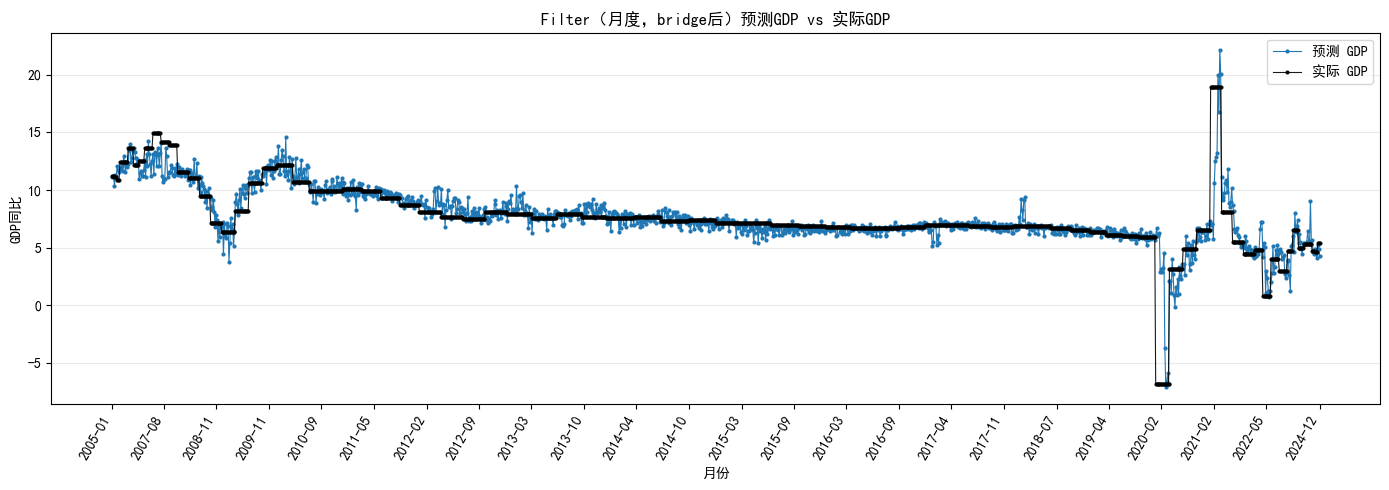

In [9]:
filter_overall = summarize_overall(
    filter_monthly,
    pred_col="bridge_gdp_raw",
    actual_col="actual_gdp_raw",
    error_col="bridge_nowcast_error_raw",
    label="filter_monthly_overall",
)
filter_by_year = summarize_by_year(
    filter_monthly,
    year_col="calendar_year",
    pred_col="bridge_gdp_raw",
    actual_col="actual_gdp_raw",
    error_col="bridge_nowcast_error_raw",
    label="filter_monthly_by_year",
)

display(filter_overall)
display(filter_by_year)

filter_overall.to_csv(SUMMARY_DIR / "filter_monthly_overall_bridge_metrics.csv", encoding="utf-8-sig", index=False)
filter_by_year.to_csv(SUMMARY_DIR / "filter_monthly_by_year_bridge_metrics.csv", encoding="utf-8-sig", index=False)

plot_monthly_predictions(
    filter_monthly,
    pred_col="bridge_gdp_raw",
    actual_col="actual_gdp_raw",
    title="Filter（月度，bridge后）预测GDP vs 实际GDP",
    png_path=SUMMARY_DIR / "filter_monthly_bridge_gdp_overall.png",
    point_size=4.0,
)


## 2. Smoother（月度重构，bridge后）

,summary_type,n_obs,mean_error_raw,mae_raw,rmse_raw,corr_raw
0,smoother_monthly_overall,1320.0,0.021461,0.463096,0.766245,0.964353


,n_obs,mean_error_raw,mae_raw,rmse_raw,corr_raw,summary_type,calendar_year
0,12.0,-0.025619,0.211404,0.251473,0.930523,smoother_monthly_by_year,2005
1,24.0,-0.267182,0.472569,0.540609,0.515205,smoother_monthly_by_year,2006
2,36.0,-1.409980,1.409980,1.559572,0.270683,smoother_monthly_by_year,2007
3,48.0,-0.300390,0.530274,0.691831,0.965962,smoother_monthly_by_year,2008
4,60.0,0.680396,0.858424,0.999695,0.940719,smoother_monthly_by_year,2009
5,72.0,0.061280,0.378198,0.520993,0.834844,smoother_monthly_by_year,2010
6,84.0,0.023838,0.233750,0.275473,0.866861,smoother_monthly_by_year,2011
7,96.0,0.441193,0.545492,0.705263,0.377617,smoother_monthly_by_year,2012
8,108.0,0.144319,0.367552,0.488284,0.160476,smoother_monthly_by_year,2013
9,120.0,-0.139832,0.315087,0.440847,0.303140,smoother_monthly_by_year,2014


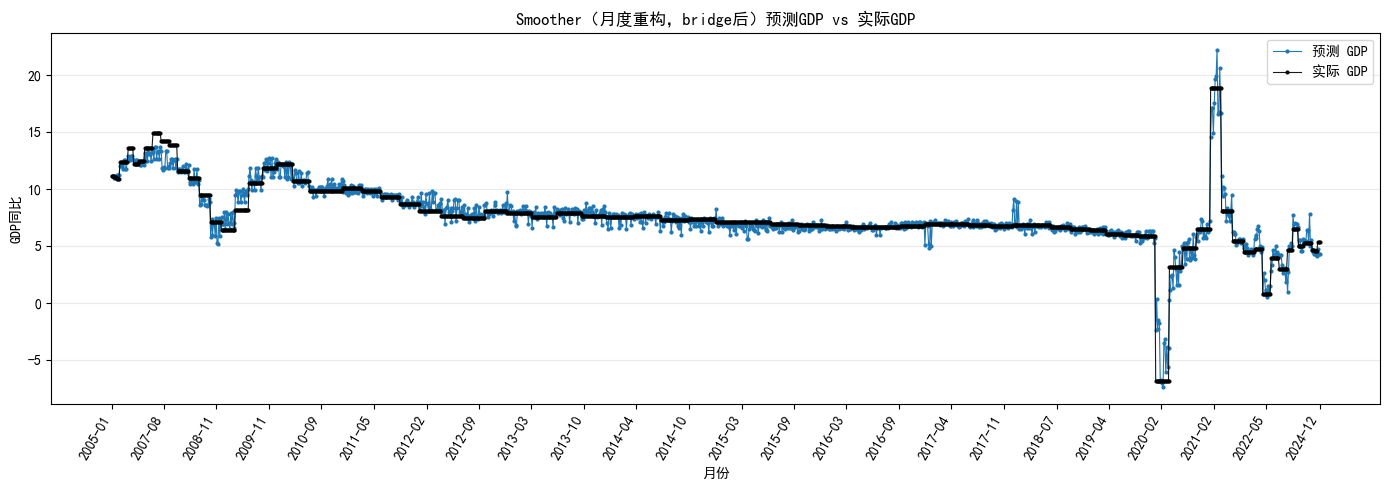

In [8]:
smoother_overall = summarize_overall(
    smoother_monthly,
    pred_col="bridge_smoother_gdp_raw",
    actual_col="actual_gdp_raw",
    error_col="error_raw",
    label="smoother_monthly_overall",
)
smoother_by_year = summarize_by_year(
    smoother_monthly,
    year_col="calendar_year",
    pred_col="bridge_smoother_gdp_raw",
    actual_col="actual_gdp_raw",
    error_col="error_raw",
    label="smoother_monthly_by_year",
)

display(smoother_overall)
display(smoother_by_year)

smoother_overall.to_csv(SUMMARY_DIR / "smoother_monthly_overall_bridge_metrics.csv", encoding="utf-8-sig", index=False)
smoother_by_year.to_csv(SUMMARY_DIR / "smoother_monthly_by_year_bridge_metrics.csv", encoding="utf-8-sig", index=False)

plot_monthly_predictions(
    smoother_monthly,
    pred_col="bridge_smoother_gdp_raw",
    actual_col="actual_gdp_raw",
    title="Smoother（月度重构，bridge后）预测GDP vs 实际GDP",
    png_path=SUMMARY_DIR / "smoother_monthly_bridge_gdp_overall.png",
    point_size=4.0,
)



## 3. Nowcasting（月度，bridge后）

,summary_type,n_obs,mean_error_raw,mae_raw,rmse_raw,corr_raw
0,nowcast_monthly_overall,132.0,0.151427,1.196796,2.662443,0.502227


,n_obs,mean_error_raw,mae_raw,rmse_raw,corr_raw,summary_type,forecast_year
0,12.0,-0.254228,0.540036,0.625321,0.359561,nowcast_monthly_by_year,2015
1,12.0,-0.456830,0.456830,0.487078,0.516489,nowcast_monthly_by_year,2016
2,12.0,0.263011,0.302080,0.373097,-0.202541,nowcast_monthly_by_year,2017
3,12.0,-0.054429,0.161263,0.189299,0.663981,nowcast_monthly_by_year,2018
4,12.0,-0.297196,0.311642,0.420950,0.667593,nowcast_monthly_by_year,2019
5,12.0,2.126647,3.767608,6.078631,-0.053812,nowcast_monthly_by_year,2020
6,12.0,-1.327687,3.512044,5.403567,0.417743,nowcast_monthly_by_year,2021
7,12.0,1.612015,1.612015,2.010800,0.663497,nowcast_monthly_by_year,2022
8,12.0,-0.198936,0.917310,1.362035,0.346851,nowcast_monthly_by_year,2023
9,12.0,0.790406,0.922778,1.960709,0.343735,nowcast_monthly_by_year,2024


,n_obs,mean_error_raw,mae_raw,rmse_raw,corr_raw,months_before_quarter_end
0,44.0,0.020376,0.803385,1.678741,0.870420,0
1,44.0,0.189185,1.324054,2.828002,0.432545,1
2,44.0,0.244721,1.462948,3.232652,0.162989,2


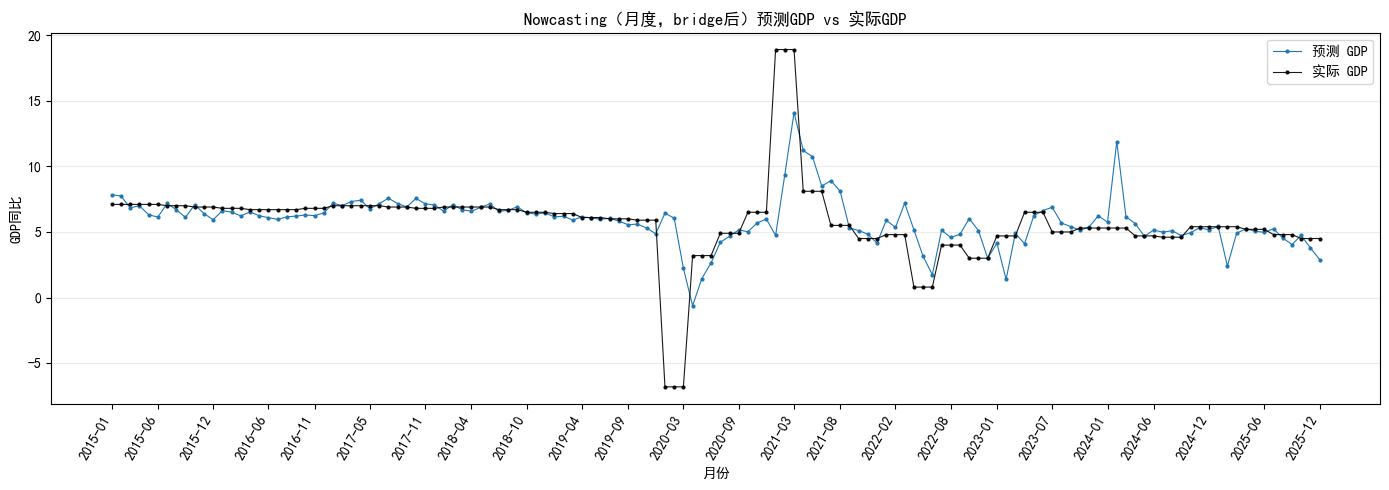

In [7]:
nowcast_overall = summarize_overall(
    nowcast_monthly,
    pred_col="bridge_gdp_raw",
    actual_col="actual_gdp_raw",
    error_col="bridge_nowcast_error_raw",
    label="nowcast_monthly_overall",
)
nowcast_by_year = summarize_by_year(
    nowcast_monthly,
    year_col="forecast_year",
    pred_col="bridge_gdp_raw",
    actual_col="actual_gdp_raw",
    error_col="bridge_nowcast_error_raw",
    label="nowcast_monthly_by_year",
)
nowcast_by_horizon = summarize_by_horizon(
    nowcast_monthly.loc[nowcast_monthly["months_before_quarter_end"].isin([0, 1, 2])].copy(),
    pred_col="bridge_gdp_raw",
    actual_col="actual_gdp_raw",
    error_col="bridge_nowcast_error_raw",
)

display(nowcast_overall)
display(nowcast_by_year)
display(nowcast_by_horizon)

nowcast_overall.to_csv(SUMMARY_DIR / "nowcast_monthly_overall_bridge_metrics.csv", encoding="utf-8-sig", index=False)
nowcast_by_year.to_csv(SUMMARY_DIR / "nowcast_monthly_by_year_bridge_metrics.csv", encoding="utf-8-sig", index=False)
nowcast_by_horizon.to_csv(SUMMARY_DIR / "nowcast_monthly_by_horizon_0_2_bridge_metrics.csv", encoding="utf-8-sig", index=False)

plot_monthly_predictions(
    nowcast_monthly,
    pred_col="bridge_gdp_raw",
    actual_col="actual_gdp_raw",
    title="Nowcasting（月度，bridge后）预测GDP vs 实际GDP",
    png_path=SUMMARY_DIR / "nowcast_monthly_bridge_gdp_overall.png",
    point_size=4.0,
)
